In [ ]:
#%pip install pandas geopandas plotly scikit-learn numpy prophet matplotlib scikit-learn seaborn
import pandas as pd
import geopandas as gpd
import plotly.express as px
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sqlite3
# Cell: Establish Database Connection
def connect_to_database(db_path="nc_energy.db"):
    """Establish connection to the SQLite database"""
    try:
        conn = sqlite3.connect(db_path)
        print(f"Successfully connected to database: {db_path}")
        return conn
    except sqlite3.Error as e:
        print(f"Error connecting to database: {e}")
        return None

# Establish connection
conn = connect_to_database()

# Verify connection by checking tables
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print("\nAvailable tables:")
    for table in tables:
        print(f"- {table[0]}")

Successfully connected to database: nc_energy.db

Available tables:
- energy_consumption
- energy_predictions
- county_populations


In [3]:
def load_and_transform_energy_data():
    # Read CSV with proper data types
    df = pd.read_csv('energy-and-utilities-linc.csv',
                     delimiter=';',
                     names=['County', 'Empty', 'Year', 'Variable', 'Value'],
                     dtype={'County': str, 'Empty': str, 'Year': str, 'Variable': str, 'Value': str})
    
    # Remove header rows and clean data
    df = df[~df['County'].isin(['Area Name', 'County'])]
    df = df[df['Value'].str.isnumeric().fillna(False)]

    # Drop empty column and convert types
    df = df.drop('Empty', axis=1)
    df['Value'] = pd.to_numeric(df['Value'])
    df['Year'] = pd.to_numeric(df['Year'])
    
    # Create pivot table
    transformed_df = pd.pivot_table(
        df,
        values='Value',
        index=['County', 'Year'],
        columns='Variable',
        aggfunc='first'
    ).reset_index()
    
    # Rename columns for clarity
    column_mapping = {
        'Occupied Housing Units Heated by Electricity': 'heated_by_electricity',
        'Occ Housing Units Heated by Gas Piped Underground': 'heated_by_gas',
        'Occupied Housing Units Heated by Fuel Oil': 'heated_by_fuel_oil',
        'Occ Housing Units Heated by Coal, Wood, Solar, or Other': 'heated_by_other',
        'Occupied Housing Units without House Heating Fuel': 'no_heating',
        'Occ Housing Units Heated by Bottled Tank or LP Gas Fuel': 'heated_by_lp_gas'
    }
    
    # Convert types and fill nulls
    transformed_df = transformed_df.rename(columns=column_mapping)
    transformed_df = transformed_df.fillna(0)
    
     # Convert to integers after cleaning
    numeric_cols = transformed_df.columns.difference(['County'])
    transformed_df[numeric_cols] = transformed_df[numeric_cols].astype(int)
    

    return transformed_df

# Cell 4: Create SQLite Database
def create_database():
    # Get transformed data
    energy_df = load_and_transform_energy_data()
    
    # Create database connection
    conn = sqlite3.connect('nc_energy.db')
    
    # Create table schema
    create_table_sql = '''
    CREATE TABLE IF NOT EXISTS energy_consumption (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    ) WITHOUT ROWID;
    '''
    conn.executescript(create_table_sql)
    energy_df.to_sql('energy_consumption', conn, if_exists='replace', index=False)
    # Insert data
    energy_df.to_sql('energy_consumption', 
                     conn, 
                     if_exists='replace', 
                     index=False,
                     dtype={
                         'County': 'TEXT',
                         'Year': 'INTEGER',
                         'heated_by_electricity': 'INTEGER',
                         'heated_by_gas': 'INTEGER',
                         'heated_by_fuel_oil': 'INTEGER',
                         'heated_by_other': 'INTEGER',
                         'no_heating': 'INTEGER',
                         'heated_by_lp_gas': 'INTEGER'
                     })
    
    return conn, energy_df

def get_county_data(conn, county_name):
    query = '''
    SELECT 
        County,
        Year,
        heated_by_electricity,
        heated_by_gas,
        heated_by_fuel_oil,
        heated_by_other,
        no_heating,
        heated_by_lp_gas
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year;
    '''
    return pd.read_sql(query, conn, params=(county_name,))

# Create database with new structure
energy_df = load_and_transform_energy_data()
print(energy_df.head())
print("\nColumns:", energy_df.columns.tolist())
print("\nData types:", energy_df.dtypes)

#Test get_county_data
conn, energy_df = create_database()
county_data = get_county_data(conn, 'Guilford County')
print(county_data.head())


Variable           County  Year  heated_by_lp_gas  heated_by_other  \
0         Alamance County  1990              4006             2541   
1         Alamance County  2000              6511             1005   
2         Alamance County  2010              6194             1243   
3         Alamance County  2015              5119             1918   
4         Alamance County  2020              4005             1101   

Variable  heated_by_gas  heated_by_electricity  heated_by_fuel_oil  no_heating  
0                 15946                  12543                7552          64  
1                 24211                  16783                2996          78  
2                 26390                  23032                2086          55  
3                 26122                  26576                1578         232  
4                 26842                  32290                 848         369  

Columns: ['County', 'Year', 'heated_by_lp_gas', 'heated_by_other', 'heated_by_gas', 'heated_

In [1]:
# Import and prepare North Carolina population data
import pandas as pd
import sqlite3
import os

# Load the census data
print("Loading historical census data...")
census_df = pd.read_csv('historic-census-2.csv')

# Clean county names if necessary
if 'AreaName' in census_df.columns:
    # Rename AreaName to County for consistency
    census_df = census_df.rename(columns={'AreaName': 'County'})

print(f"Original census data shape: {census_df.shape}")
print(census_df.head())

# Pivot the data to have years as columns
population_pivot = census_df.pivot(index='County', columns='Year', values='Population')

# Reset index to make County a regular column
county_populations = population_pivot.reset_index()

# Ensure all expected years are present as columns
expected_years = [1990, 2000, 2010, 2020]
for year in expected_years:
    if year not in county_populations.columns:
        county_populations[year] = None

# Keep only the columns we need
county_populations = county_populations[['County'] + expected_years]

# Rename columns to be more descriptive
county_populations.columns = ['County', 'Population_1990', 'Population_2000', 'Population_2010', 'Population_2020']

print(f"Transformed county population data shape: {county_populations.shape}")
print(county_populations.head())

# Connect to SQLite database
db_path = 'nc_energy.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Create a new table for county populations
print("Creating county_populations table in database...")
cursor.execute('''
DROP TABLE IF EXISTS county_populations
''')

cursor.execute('''
CREATE TABLE county_populations (
    County TEXT PRIMARY KEY,
    Population_1990 INTEGER,
    Population_2000 INTEGER,
    Population_2010 INTEGER,
    Population_2020 INTEGER
)
''')

# Insert data into the table
county_populations.to_sql('county_populations', conn, if_exists='replace', index=False)

# Verify the data was inserted correctly
print("Verifying data insertion...")
verification = pd.read_sql_query("SELECT * FROM county_populations LIMIT 5", conn)
print(verification)

# Count the rows in the table
row_count = pd.read_sql_query("SELECT COUNT(*) FROM county_populations", conn).iloc[0, 0]
print(f"Total counties in population table: {row_count}")

# Close connection
conn.close()

print("County population data successfully loaded into the database!")

Loading historical census data...
Original census data shape: (400, 3)
      County  Year  Population
0  Alexander  2010       37198
1     Bertie  2010       21282
2  Brunswick  2020      136693
3   Caldwell  2000       77708
4     Camden  1990        5904
Transformed county population data shape: (100, 5)
      County  Population_1990  Population_2000  Population_2010  \
0   Alamance           108213           130800           151131   
1  Alexander            27544            33603            37198   
2  Alleghany             9590            10680            11155   
3      Anson            23474            25275            26948   
4       Ashe            22209            24384            27281   

   Population_2020  
0           171415  
1            36444  
2            10888  
3            22055  
4            26577  
Creating county_populations table in database...
Verifying data insertion...
      County  Population_1990  Population_2000  Population_2010  \
0   Alamance       

In [6]:
# Fix county name format

def standardize_county_names(conn):
    """
    Standardize county names between energy_consumption and county_populations tables
    to ensure they can be properly joined
    """
    print("Standardizing county names in population data...")
    
    # Get county names from energy_consumption
    energy_counties = pd.read_sql_query("SELECT DISTINCT County FROM energy_consumption", conn)
    energy_counties['BaseCounty'] = energy_counties['County'].str.replace(' County', '')
    
    # Get county names from county_populations
    pop_counties = pd.read_sql_query("SELECT DISTINCT County FROM county_populations", conn)
    
    # Check format differences
    print(f"Energy counties (first 5): {energy_counties['County'].head().tolist()}")
    print(f"Population counties (first 5): {pop_counties['County'].head().tolist()}")
    
    # If population counties don't end with " County", add it to match energy_consumption
    needs_update = False
    for _, energy_row in energy_counties.iterrows():
        energy_county = energy_row['County']
        base_county = energy_row['BaseCounty']
        
        # Check if we need to add "County" suffix
        if energy_county.endswith(' County') and base_county in pop_counties['County'].values:
            needs_update = True
            break
    
    if needs_update:
        print("County name format mismatch detected. Updating population table...")
        
        # Get current population data
        pop_data = pd.read_sql_query("SELECT * FROM county_populations", conn)
        
        # Create a mapping between existing county names and standardized names
        county_mapping = {}
        
        for idx, pop_row in pop_data.iterrows():
            pop_county = pop_row['County']
            
            # Find matching energy county
            for _, energy_row in energy_counties.iterrows():
                energy_county = energy_row['County']
                base_county = energy_row['BaseCounty']
                
                # If the base county name matches, use the energy county name format
                if pop_county == base_county or pop_county.lower() == base_county.lower():
                    county_mapping[pop_county] = energy_county
                    break
        
        # Update population data with standardized county names
        new_pop_data = pop_data.copy()
        for old_name, new_name in county_mapping.items():
            new_pop_data.loc[new_pop_data['County'] == old_name, 'County'] = new_name
            
        # Display changes
        changes = [(old, new) for old, new in county_mapping.items() if old != new]
        if changes:
            print("County name changes:")
            for old, new in changes:
                print(f"  {old} -> {new}")
                
            # Drop existing table and create new one
            cursor = conn.cursor()
            cursor.execute("DROP TABLE IF EXISTS county_populations")
            conn.commit()
            
            # Write updated data back to database
            new_pop_data.to_sql('county_populations', conn, if_exists='replace', index=False)
            print(f"Updated {len(changes)} county names in population table")
        else:
            print("No county name updates needed")
    else:
        print("County name formats appear to be consistent")
        
    # Verify the join works correctly
    test_query = """
    SELECT e.County as EnergyCounty, p.County as PopCounty
    FROM energy_consumption e
    JOIN county_populations p ON e.County = p.County
    GROUP BY e.County
    """
    test_result = pd.read_sql_query(test_query, conn)
    print(f"Successfully joined {len(test_result)} counties between energy and population data")
    
    return len(test_result)

# Run the function to standardize county names
joined_count = standardize_county_names(conn)
print(f"Ready to generate predictions with {joined_count} counties that have population data")

Standardizing county names in population data...
Energy counties (first 5): ['Alamance County', 'Alexander County', 'Alleghany County', 'Anson County', 'Ashe County']
Population counties (first 5): ['Alamance', 'Alexander', 'Alleghany', 'Anson', 'Ashe']
County name format mismatch detected. Updating population table...
County name changes:
  Alamance -> Alamance County
  Alexander -> Alexander County
  Alleghany -> Alleghany County
  Anson -> Anson County
  Ashe -> Ashe County
  Avery -> Avery County
  Beaufort -> Beaufort County
  Bertie -> Bertie County
  Bladen -> Bladen County
  Brunswick -> Brunswick County
  Buncombe -> Buncombe County
  Burke -> Burke County
  Cabarrus -> Cabarrus County
  Caldwell -> Caldwell County
  Camden -> Camden County
  Carteret -> Carteret County
  Caswell -> Caswell County
  Catawba -> Catawba County
  Chatham -> Chatham County
  Cherokee -> Cherokee County
  Chowan -> Chowan County
  Clay -> Clay County
  Cleveland -> Cleveland County
  Columbus -> Co

In [ ]:
# Cell 4: Query Functions
#Specific County Data
def get_county_data(conn, county_name):
    query = '''
    SELECT * FROM energy_consumption 
    WHERE county = ? 
    ORDER BY Year
    '''
    return pd.read_sql_query(query, conn, params=[county_name])

#County List
def get_county_list(conn):
    query = '''
    SELECT DISTINCT county FROM energy_consumption
    '''
    return pd.read_sql_query(query, conn)

#Select largest counties
def get_largest_counties(conn, n=5):
    query = '''
    SELECT county, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY county
    ORDER BY total_energy DESC
    LIMIT ?
    '''
    return pd.read_sql_query(query, conn, params=[n])

#Select total energy by year
def get_total_energy_by_year(conn):
    query = '''
    SELECT year, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY year
    '''
    return pd.read_sql_query(query, conn)

#Print the returned queries
print(get_county_list(conn))
print(get_county_data(conn, 'Guilford County').head())

              County
0    Alamance County
1   Alexander County
2   Alleghany County
3       Anson County
4        Ashe County
..               ...
95      Wayne County
96     Wilkes County
97     Wilson County
98     Yadkin County
99     Yancey County

[100 rows x 1 columns]
            County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0  Guilford County  1990              4291             5438          48770   
1  Guilford County  2000              7941             2034          76608   
2  Guilford County  2010              7944             1771          85699   
3  Guilford County  2015              6445             1999          82119   
4  Guilford County  2020              6132             1926          85206   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  57535               21482         190  
1                  71024               10715         345  
2                  87088                6580         479  
3                 1

In [9]:
# Cell: ML Predictions with Prophet (Enhanced with Population Data)

def create_prophet_predictions(conn, county_name, heating_type):
    """
    Generate Prophet predictions for a county and heating type using population data as a regressor
    to improve forecast accuracy and prevent unrealistic negative values.
    """
    # First, check the format of county names in both tables
    print(f"Finding population data for: {county_name}")
    
    # Extract base county name (without 'County' suffix if present)
    base_county_name = county_name.replace(' County', '')
    
    # Get historical energy data with flexible county name matching
    query = f"""
    SELECT e.Year, e.{heating_type}, 
           CASE 
               WHEN e.Year = 1990 THEN p.Population_1990
               WHEN e.Year = 2000 THEN p.Population_2000
               WHEN e.Year = 2010 THEN p.Population_2010
               WHEN e.Year = 2020 THEN p.Population_2020
               ELSE NULL
           END as Population
    FROM energy_consumption e
    JOIN county_populations p ON (
        p.County = e.County OR 
        p.County = REPLACE(e.County, ' County', '') OR
        e.County = p.County || ' County'
    )
    WHERE e.County = ?
    ORDER BY e.Year
    """
    df = pd.read_sql_query(query, conn, params=[county_name])
    
    if df.empty:
        print(f"No joined data found. Trying alternative approach for {county_name}...")
        
        # Get energy data first
        energy_query = f"""
        SELECT Year, {heating_type}
        FROM energy_consumption
        WHERE County = ?
        ORDER BY Year
        """
        df = pd.read_sql_query(energy_query, conn, params=[county_name])
        
        if df.empty:
            print(f"No energy data found for {county_name}")
            return None, None
            
        # Check population data with different name formats
        pop_query = """
        SELECT County, Population_1990, Population_2000, Population_2010, Population_2020
        FROM county_populations
        WHERE County = ? OR County = ? OR County LIKE ?
        """
        pop_df = pd.read_sql_query(pop_query, conn, 
                                 params=[county_name, base_county_name, f"{base_county_name}%"])
        
        if pop_df.empty:
            # Try a more fuzzy approach - get all county names and find closest match
            all_counties = pd.read_sql_query("SELECT County FROM county_populations", conn)
            print(f"Available counties in population data: {all_counties['County'].tolist()}")
            
            # Try to find the closest match
            for idx, pop_county in all_counties.iterrows():
                if base_county_name.lower() in pop_county['County'].lower() or \
                   pop_county['County'].lower() in base_county_name.lower():
                    print(f"Found potential match: {pop_county['County']} for {county_name}")
                    pop_df = pd.read_sql_query(
                        "SELECT * FROM county_populations WHERE County = ?", 
                        conn, params=[pop_county['County']]
                    )
                    break
        
        if pop_df.empty:
            print(f"No population data found for {county_name} after all attempts")
            return None, None
            
        print(f"Found population data for {county_name} using alternate matching: {pop_df['County'].iloc[0]}")
        
        # Manually join the data
        years = df['Year'].unique()
        population_values = []
        
        for year in years:
            if year == 1990 and not pd.isna(pop_df['Population_1990'].iloc[0]):
                population_values.append(pop_df['Population_1990'].iloc[0])
            elif year == 2000 and not pd.isna(pop_df['Population_2000'].iloc[0]):
                population_values.append(pop_df['Population_2000'].iloc[0])
            elif year == 2010 and not pd.isna(pop_df['Population_2010'].iloc[0]):
                population_values.append(pop_df['Population_2010'].iloc[0])
            elif year == 2020 and not pd.isna(pop_df['Population_2020'].iloc[0]):
                population_values.append(pop_df['Population_2020'].iloc[0])
            else:
                population_values.append(None)
                
        df['Population'] = population_values
    else:
        print(f"Successfully joined energy and population data for {county_name}")
    
    # Verify we have some population data
    if 'Population' not in df.columns or df['Population'].isnull().all():
        print(f"No valid population values for {county_name}")
        return None, None
        
    print(f"Population data for {county_name}: {df['Population'].dropna().tolist()}")
    
    # Get population data for future years (simple linear extrapolation)
    pop_df = df[['Year', 'Population']].dropna().drop_duplicates('Year')
    
    if len(pop_df) < 2:
        print(f"Insufficient population data points for {county_name}")
        return None, None
    
    # Calculate population trend and extrapolate for future years
    pop_series = pd.Series(pop_df['Population'].values, index=pop_df['Year'].values)
    
    # Fill NaN values with median to avoid extrapolation problems
    pop_series = pop_series.fillna(pop_series.median())
    
    # Calculate future populations using linear regression
    years = np.array(pop_series.index).reshape(-1, 1)
    values = np.array(pop_series.values)
    
    # Ensure we have valid population data
    if len(years) < 2 or np.isnan(values).any() or np.all(values == 0):
        print(f"Insufficient population data for regression for {county_name}")
        # Use a simple growth rate instead
        latest_pop = pop_series.iloc[-1]
        future_pop = {
            2025: latest_pop * 1.02,
            2030: latest_pop * 1.04,
            2035: latest_pop * 1.06,
            2040: latest_pop * 1.08
        }
    else:
        from sklearn.linear_model import LinearRegression
        model = LinearRegression()
        model.fit(years, values)
        
        # Predict future populations
        future_years = np.array([2025, 2030, 2035, 2040]).reshape(-1, 1)
        future_populations = model.predict(future_years)
        
        # Ensure predictions are positive
        future_populations = np.maximum(future_populations, 100)  # Minimum population of 100
        
        future_pop = {
            year: pop for year, pop in zip([2025, 2030, 2035, 2040], future_populations)
        }
    
    # Prepare data for Prophet with population as a regressor
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['Year'].astype(str)),
        'y': df[heating_type],
        'population': df['Population']
    })
    
    # Fill missing population values with interpolation
    if prophet_df['population'].isna().any():
        prophet_df['population'] = prophet_df['population'].interpolate(method='linear')
    
    # Add per capita column to help with scaling
    prophet_df['per_capita'] = prophet_df['y'] / prophet_df['population']
    prophet_df['per_capita'] = prophet_df['per_capita'].fillna(prophet_df['per_capita'].median())
    
    print(f"Training data: {len(prophet_df)} points from {prophet_df['ds'].min().year} to {prophet_df['ds'].max().year}")
    
    # Create and train model
    model = Prophet(
        yearly_seasonality=False,
        growth='linear',
        changepoint_prior_scale=0.1  # More conservative to prevent overfit
    )
    
    # Add population as a regressor
    model.add_regressor('population')
    
    # Fit the model
    model.fit(prophet_df)
    
    # Create future dates and add population regressor
    future = pd.DataFrame({
        'ds': pd.date_range(
            start='1990-01-01', 
            end='2040-12-31',
            freq='5YE'  # Every 5 years ending December
        )
    })
    
    # Add historical and future population data to future DataFrame
    future['population'] = future['ds'].dt.year.map(lambda y: 
        pop_series.get(y, future_pop.get(y, None))
    )
    
    # Interpolate any missing population values
    future['population'] = future['population'].interpolate(method='linear')
    
    # Generate predictions
    forecast = model.predict(future)
    
    # Calculate per capita and total values for sanity check
    forecast['per_capita'] = forecast['yhat'] / forecast['population']
    
    # Ensure predictions are non-negative
    forecast['yhat'] = np.maximum(forecast['yhat'], 0)
    forecast['yhat_lower'] = np.maximum(forecast['yhat_lower'], 0)
    
    # Round to integers for housing units
    forecast['yhat'] = forecast['yhat'].round().astype(int)
    
    # Create prediction DataFrame for database
    predictions = pd.DataFrame({
        'County': county_name,
        'Year': forecast['ds'].dt.year,
        heating_type: forecast['yhat']
    })
    
    # Filter to only include prediction years (2025-2040)
    predictions = predictions[predictions['Year'] >= 2025]
    
    # Also return the per capita values for validation
    predictions['per_capita'] = forecast[forecast['ds'].dt.year >= 2025]['per_capita'].values
    
    print(f"Generated {len(predictions)} predictions for {county_name}, {heating_type}")
    
    return predictions[['County', 'Year', heating_type]], model

# Function to generate predictions for all counties and heating types
def generate_and_store_predictions(conn):
    """Generate predictions for all counties and all heating types using population data"""
    # Get all counties
    counties = pd.read_sql_query("SELECT DISTINCT County FROM energy_consumption", conn)
    
    # Get all heating types (excluding County and Year columns)
    heating_types = [col for col in pd.read_sql_query("SELECT * FROM energy_consumption LIMIT 1", conn).columns 
                    if col not in ['County', 'Year']]
    
    # Create predictions table if it doesn't exist
    create_predictions_table = """
    CREATE TABLE IF NOT EXISTS energy_predictions (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    )
    """
    conn.execute("DROP TABLE IF EXISTS energy_predictions")
    conn.execute(create_predictions_table)
    
    # Generate predictions for each county and heating type
    all_predictions = []
    
    for _, county_row in counties.iterrows():
        county = county_row['County']
        print(f"Generating predictions for {county}...")
        
        county_predictions = {}
        for heating_type in heating_types:
            try:
                predictions, _ = create_prophet_predictions(conn, county, heating_type)
                if predictions is not None:
                    county_predictions[heating_type] = predictions[heating_type].values
                else:
                    # Fallback to simple trend if prediction fails
                    print(f"Using fallback prediction for {county}, {heating_type}")
                    county_data = pd.read_sql_query(
                        f"SELECT Year, {heating_type} FROM energy_consumption WHERE County = ? ORDER BY Year",
                        conn, params=[county]
                    )
                    if not county_data.empty:
                        latest_value = county_data[heating_type].iloc[-1]
                        # Simple trend: maintain latest value with slight growth
                        county_predictions[heating_type] = np.array([
                            max(0, int(latest_value * 1.02)),
                            max(0, int(latest_value * 1.04)),
                            max(0, int(latest_value * 1.06)),
                            max(0, int(latest_value * 1.08))
                        ])
                    else:
                        county_predictions[heating_type] = np.array([0, 0, 0, 0])
            except Exception as e:
                print(f"Error generating predictions for {county}, {heating_type}: {e}")
                # Fallback to zeros if completely failed
                county_predictions[heating_type] = np.array([0, 0, 0, 0])
        
        # Combine predictions for all heating types
        for year_idx, year in enumerate(range(2025, 2041, 5)):
            prediction_row = {
                'County': county,
                'Year': year
            }
            for heating_type in heating_types:
                if heating_type in county_predictions and county_predictions[heating_type] is not None:
                    if year_idx < len(county_predictions[heating_type]):
                        prediction_row[heating_type] = int(county_predictions[heating_type][year_idx])
                    else:
                        prediction_row[heating_type] = 0
                else:
                    prediction_row[heating_type] = 0
            
            all_predictions.append(prediction_row)
    
    # Convert to DataFrame and store in database
    predictions_df = pd.DataFrame(all_predictions)
    predictions_df.to_sql('energy_predictions', conn, if_exists='replace', index=False)
    
    print("Predictions generated and stored in database.")
    return predictions_df

# Generate and store predictions
predictions_df = generate_and_store_predictions(conn)

# Display sample of predictions
print("\nSample of generated predictions:")
print(predictions_df.head())

# Verify data in database
print("\nVerifying data in database:")
print(pd.read_sql_query("SELECT * FROM energy_predictions LIMIT 5", conn))

Generating predictions for Alamance County...
Finding population data for: Alamance County
Successfully joined energy and population data for Alamance County
Population data for Alamance County: [108213.0, 130800.0, 151131.0, 171415.0]
Training data: 5 points from 1990 to 2020


19:01:25 - cmdstanpy - INFO - Chain [1] start processing
19:01:26 - cmdstanpy - INFO - Chain [1] done processing
19:01:26 - cmdstanpy - INFO - Chain [1] start processing


Generated 4 predictions for Alamance County, heated_by_lp_gas
Finding population data for: Alamance County
Successfully joined energy and population data for Alamance County
Population data for Alamance County: [108213.0, 130800.0, 151131.0, 171415.0]
Training data: 5 points from 1990 to 2020


19:01:26 - cmdstanpy - INFO - Chain [1] done processing
19:01:26 - cmdstanpy - INFO - Chain [1] start processing


Generated 4 predictions for Alamance County, heated_by_other
Finding population data for: Alamance County
Successfully joined energy and population data for Alamance County
Population data for Alamance County: [108213.0, 130800.0, 151131.0, 171415.0]
Training data: 5 points from 1990 to 2020


...

Generated 4 predictions for Yancey County, heated_by_lp_gas
Finding population data for: Yancey County
Successfully joined energy and population data for Yancey County
Population data for Yancey County: [15419.0, 17774.0, 17818.0, 18470.0]
Training data: 5 points from 1990 to 2020
Generated 4 predictions for Yancey County, heated_by_other
Finding population data for: Yancey County
Successfully joined energy and population data for Yancey County
Population data for Yancey County: [15419.0, 17774.0, 17818.0, 18470.0]
Training data: 5 points from 1990 to 2020


19:04:11 - cmdstanpy - INFO - Chain [1] done processing
19:04:11 - cmdstanpy - INFO - Chain [1] start processing
19:04:11 - cmdstanpy - INFO - Chain [1] done processing
19:04:11 - cmdstanpy - INFO - Chain [1] start processing


Generated 4 predictions for Yancey County, heated_by_gas
Finding population data for: Yancey County
Successfully joined energy and population data for Yancey County
Population data for Yancey County: [15419.0, 17774.0, 17818.0, 18470.0]
Training data: 5 points from 1990 to 2020
Generated 4 predictions for Yancey County, heated_by_electricity
Finding population data for: Yancey County
Successfully joined energy and population data for Yancey County
Population data for Yancey County: [15419.0, 17774.0, 17818.0, 18470.0]
Training data: 5 points from 1990 to 2020


19:04:11 - cmdstanpy - INFO - Chain [1] done processing
19:04:11 - cmdstanpy - INFO - Chain [1] start processing
19:04:11 - cmdstanpy - INFO - Chain [1] done processing


Generated 4 predictions for Yancey County, heated_by_fuel_oil
Finding population data for: Yancey County
Successfully joined energy and population data for Yancey County
Population data for Yancey County: [15419.0, 17774.0, 17818.0, 18470.0]
Training data: 5 points from 1990 to 2020
Generated 4 predictions for Yancey County, no_heating
Predictions generated and stored in database.

Sample of generated predictions:
             County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0   Alamance County  2025              3784             1342          24397   
1   Alamance County  2030              3779             1192          26089   
2   Alamance County  2035              3774             1042          27782   
3   Alamance County  2040              3765              893          29460   
4  Alexander County  2025               994              233            576   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  40207                1949    

1. Basic verification of the prediction data
   total_rows  county_count  min_year  max_year
0         400           100      2025      2040

2. Sample of prediction data for a few counties
                County  Year  heated_by_electricity  heated_by_gas  \
0      Guilford County  2025                 124901          88811   
1      Guilford County  2030                 134147          94442   
2      Guilford County  2035                 143393         100073   
3      Guilford County  2040                 152653         105685   
4   Mecklenburg County  2025                 242161         247179   
5   Mecklenburg County  2030                 272221         268037   
6   Mecklenburg County  2035                 302281         288895   
7   Mecklenburg County  2040                 332350         309781   
8          Wake County  2025                 251639         200969   
9          Wake County  2030                 280915         221488   
10         Wake County  2035            

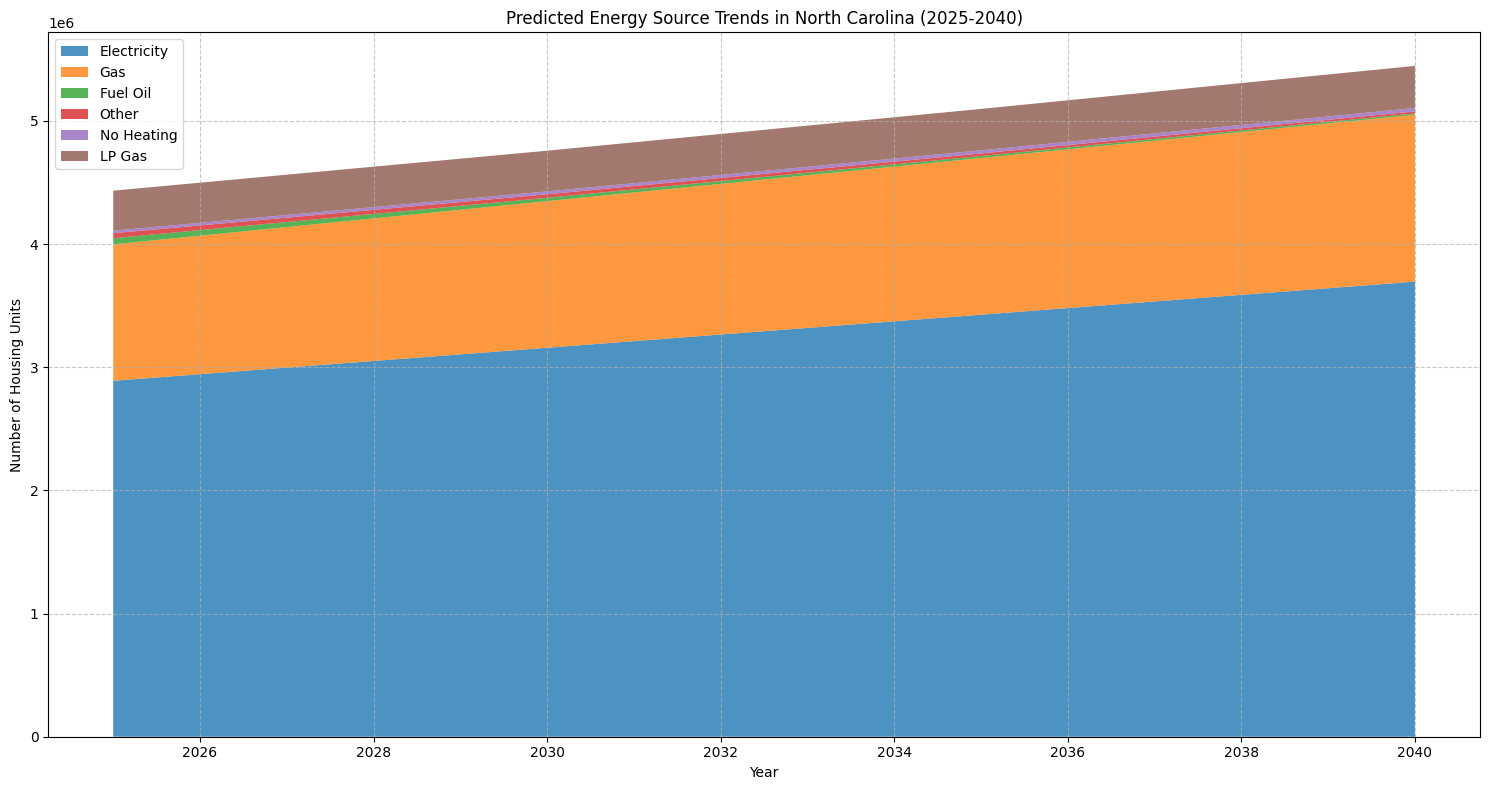


9. Correlation between population and electricity usage
Sample county formats in tables:
           table_name            County  count
0  energy_predictions   Alamance County      4
1  energy_predictions  Alexander County      4
2  energy_predictions  Alleghany County      4
3  energy_predictions      Anson County      4
4  energy_predictions       Ashe County      4
5  energy_predictions      Avery County      4
6  energy_predictions   Beaufort County      4
7  energy_predictions     Bertie County      4
8  energy_predictions     Bladen County      4
9  energy_predictions  Brunswick County      4
Successfully matched 0 counties with population data
Empty DataFrame
Columns: [County, Year, heated_by_electricity, estimated_population]
Index: []
No matching county population data found. Check county name formats in both tables.


In [12]:
# Queries to check energy prediction data in the database

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
conn = sqlite3.connect('nc_energy.db')

print("1. Basic verification of the prediction data")
basic_check = pd.read_sql_query("""
SELECT COUNT(*) AS total_rows, 
       COUNT(DISTINCT County) AS county_count,
       MIN(Year) AS min_year,
       MAX(Year) AS max_year
FROM energy_predictions
""", conn)
print(basic_check)

print("\n2. Sample of prediction data for a few counties")
sample_data = pd.read_sql_query("""
SELECT County, Year, 
       heated_by_electricity, heated_by_gas, 
       heated_by_fuel_oil, heated_by_other, 
       no_heating, heated_by_lp_gas
FROM energy_predictions
WHERE County IN ('Wake County', 'Guilford County', 'Mecklenburg County')
ORDER BY County, Year
""", conn)
print(sample_data)

print("\n3. Check for negative values (should be none)")
negative_check = pd.read_sql_query("""
SELECT County, Year,
       MIN(heated_by_electricity) AS min_electricity,
       MIN(heated_by_gas) AS min_gas,
       MIN(heated_by_fuel_oil) AS min_fuel_oil,
       MIN(heated_by_other) AS min_other,
       MIN(no_heating) AS min_no_heating,
       MIN(heated_by_lp_gas) AS min_lp_gas
FROM energy_predictions
GROUP BY County
HAVING min_electricity < 0 OR min_gas < 0 OR min_fuel_oil < 0 OR 
       min_other < 0 OR min_no_heating < 0 OR min_lp_gas < 0
""", conn)
print(f"Counties with negative values: {len(negative_check)}")
if not negative_check.empty:
    print(negative_check)

print("\n4. Total energy consumption by year (all counties)")
yearly_totals = pd.read_sql_query("""
SELECT Year,
       SUM(heated_by_electricity) AS total_electricity,
       SUM(heated_by_gas) AS total_gas,
       SUM(heated_by_fuel_oil) AS total_fuel_oil,
       SUM(heated_by_other) AS total_other,
       SUM(no_heating) AS total_no_heating,
       SUM(heated_by_lp_gas) AS total_lp_gas,
       SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + 
           heated_by_other + no_heating + heated_by_lp_gas) AS grand_total
FROM energy_predictions
GROUP BY Year
ORDER BY Year
""", conn)
print(yearly_totals)

print("\n5. Counties with highest predicted growth in electricity usage (2025-2040)")
growth_analysis = pd.read_sql_query("""
WITH CountyGrowth AS (
    SELECT County,
           MAX(CASE WHEN Year = 2025 THEN heated_by_electricity ELSE 0 END) AS start_value,
           MAX(CASE WHEN Year = 2040 THEN heated_by_electricity ELSE 0 END) AS end_value
    FROM energy_predictions
    WHERE Year IN (2025, 2040)
    GROUP BY County
)
SELECT County, 
       start_value, 
       end_value,
       end_value - start_value AS absolute_growth,
       CASE 
           WHEN start_value > 0 THEN ROUND((end_value - start_value) * 100.0 / start_value, 2)
           ELSE 0
       END AS percentage_growth
FROM CountyGrowth
ORDER BY absolute_growth DESC
LIMIT 10
""", conn)
print(growth_analysis)

print("\n6. Compare predictions with historical data for 2020")
comparison_2020 = pd.read_sql_query("""
SELECT h.County, 
       h.heated_by_electricity AS hist_electricity,
       p.heated_by_electricity AS pred_electricity,
       ROUND((p.heated_by_electricity - h.heated_by_electricity) * 100.0 / h.heated_by_electricity, 2) AS pct_diff_electricity,
       h.heated_by_gas AS hist_gas,
       p.heated_by_gas AS pred_gas,
       ROUND((p.heated_by_gas - h.heated_by_gas) * 100.0 / NULLIF(h.heated_by_gas, 0), 2) AS pct_diff_gas
FROM energy_consumption h
JOIN energy_predictions p ON h.County = p.County
WHERE h.Year = 2020 AND p.Year = 2025
ORDER BY pct_diff_electricity DESC
LIMIT 15
""", conn)
print(comparison_2020)

print("\n7. Energy mix in 2040 vs 2025 (percentage of each type)")
energy_mix = pd.read_sql_query("""
WITH YearlyTotals AS (
    SELECT Year,
           SUM(heated_by_electricity) AS total_electricity,
           SUM(heated_by_gas) AS total_gas,
           SUM(heated_by_fuel_oil) AS total_fuel_oil,
           SUM(heated_by_other) AS total_other,
           SUM(no_heating) AS total_no_heating,
           SUM(heated_by_lp_gas) AS total_lp_gas,
           SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + 
               heated_by_other + no_heating + heated_by_lp_gas) AS grand_total
    FROM energy_predictions
    WHERE Year IN (2025, 2040)
    GROUP BY Year
)
SELECT Year,
       ROUND(total_electricity * 100.0 / grand_total, 2) AS pct_electricity,
       ROUND(total_gas * 100.0 / grand_total, 2) AS pct_gas,
       ROUND(total_fuel_oil * 100.0 / grand_total, 2) AS pct_fuel_oil,
       ROUND(total_other * 100.0 / grand_total, 2) AS pct_other,
       ROUND(total_no_heating * 100.0 / grand_total, 2) AS pct_no_heating,
       ROUND(total_lp_gas * 100.0 / grand_total, 2) AS pct_lp_gas
FROM YearlyTotals
ORDER BY Year
""", conn)
print(energy_mix)

print("\n8. Outlier detection - counties with unusually high growth rates")
outliers = pd.read_sql_query("""
WITH GrowthRates AS (
    SELECT County, 
           heated_by_electricity,
           Year,
           LAG(heated_by_electricity) OVER (PARTITION BY County ORDER BY Year) AS prev_value,
           Year - LAG(Year) OVER (PARTITION BY County ORDER BY Year) AS year_diff
    FROM energy_predictions
    ORDER BY County, Year
),
AnnualGrowth AS (
    SELECT County,
           Year,
           heated_by_electricity,
           prev_value,
           CASE 
               WHEN year_diff > 0 AND prev_value > 0 
               THEN POWER((heated_by_electricity / prev_value), (1.0/year_diff)) - 1 
               ELSE 0 
           END AS annual_growth_rate
    FROM GrowthRates
    WHERE prev_value IS NOT NULL AND year_diff > 0
)
SELECT County, Year, heated_by_electricity, prev_value, 
       ROUND(annual_growth_rate * 100, 2) AS annual_growth_pct
FROM AnnualGrowth
WHERE annual_growth_rate > 0.10  -- More than 10% annual growth
ORDER BY annual_growth_rate DESC
LIMIT 15
""", conn)
print(outliers)

# Visualize some of the data
plt.figure(figsize=(15, 8))

# Get data for visualization
trend_data = pd.read_sql_query("""
SELECT Year, 
       SUM(heated_by_electricity) AS total_electricity,
       SUM(heated_by_gas) AS total_gas,
       SUM(heated_by_fuel_oil) AS total_fuel_oil,
       SUM(heated_by_other) AS total_other,
       SUM(no_heating) AS total_no_heating,
       SUM(heated_by_lp_gas) AS total_lp_gas
FROM energy_predictions
GROUP BY Year
ORDER BY Year
""", conn)

# Create stacked area chart
plt.stackplot(trend_data['Year'], 
              [trend_data['total_electricity'], 
               trend_data['total_gas'],
               trend_data['total_fuel_oil'],
               trend_data['total_other'],
               trend_data['total_no_heating'],
               trend_data['total_lp_gas']],
              labels=['Electricity', 'Gas', 'Fuel Oil', 'Other', 'No Heating', 'LP Gas'],
              alpha=0.8)

plt.title('Predicted Energy Source Trends in North Carolina (2025-2040)')
plt.xlabel('Year')
plt.ylabel('Number of Housing Units')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('energy_predictions_trend.png')
plt.show()

# Correlation with population - FIXED QUERY
print("\n9. Correlation between population and electricity usage")

# First check the county name formats in both tables
county_formats = pd.read_sql_query("""
SELECT 'energy_predictions' as table_name, County, COUNT(*) as count
FROM energy_predictions
GROUP BY County
UNION ALL
SELECT 'county_populations' as table_name, County, COUNT(*) as count
FROM county_populations
GROUP BY County
LIMIT 10
""", conn)
print("Sample county formats in tables:")
print(county_formats)

# More robust population correlation query with multiple matching approaches
pop_correlation = pd.read_sql_query("""
WITH pred_counties AS (
    SELECT DISTINCT County, 
           REPLACE(County, ' County', '') AS base_county
    FROM energy_predictions
),
pop_counties AS (
    SELECT DISTINCT County,
           County || ' County' AS full_county
    FROM county_populations
)
SELECT e.County, 
       e.Year,
       e.heated_by_electricity,
       CASE 
           WHEN e.Year = 2025 THEN p.Population_2020 * 1.02
           WHEN e.Year = 2030 THEN p.Population_2020 * 1.04
           WHEN e.Year = 2035 THEN p.Population_2020 * 1.06
           WHEN e.Year = 2040 THEN p.Population_2020 * 1.08
       END AS estimated_population
FROM energy_predictions e
JOIN pred_counties pc ON e.County = pc.County
LEFT JOIN county_populations p ON p.County = pc.base_county
WHERE e.Year >= 2025 AND p.County IS NOT NULL
ORDER BY e.County, e.Year
""", conn)

print(f"Successfully matched {len(pop_correlation) // 4} counties with population data")
print(pop_correlation.head(10))

# Close connection
conn.close()

# Calculate correlations
if not pop_correlation.empty:
    correlations = pop_correlation.corr()
    print("Correlation between population and electricity usage:")
    print(correlations.loc['estimated_population', 'heated_by_electricity'])
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='estimated_population', y='heated_by_electricity', data=pop_correlation)
    plt.title('Correlation: Population vs Electricity Usage')
    plt.xlabel('Estimated Population')
    plt.ylabel('Electricity Heated Housing Units')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('population_electricity_correlation.png')
    plt.show()
else:
    print("No matching county population data found. Check county name formats in both tables.")

In [5]:
# Cell: Combine Historical and Predicted Data

def combine_historical_and_predictions(conn, output_file="nc_energy_combined.csv"):
    """Combine historical data and predictions into a single CSV file"""
    
    # Get historical data
    historical = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_consumption
        ORDER BY County, Year
    """, conn)
    
    # Get predictions
    predictions = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_predictions
        ORDER BY County, Year
    """, conn)
    
    # Combine datasets
    combined_data = pd.concat([historical, predictions], axis=0)
    
    # Sort by county and year
    combined_data = combined_data.sort_values(['County', 'Year'])
    
    # Save to CSV
    combined_data.to_csv(output_file, index=False)
    
    print(f"Combined data saved to {output_file}")
    print("\nSample of combined data:")
    print(combined_data.head(10))
    
    # Display some statistics
    print("\nYear range in combined dataset:")
    print(f"Earliest year: {combined_data['Year'].min()}")
    print(f"Latest year: {combined_data['Year'].max()}")
    print(f"\nTotal number of counties: {len(combined_data['County'].unique())}")
    print(f"Total number of records: {len(combined_data)}")

# Execute the combination
combine_historical_and_predictions(conn)

Combined data saved to nc_energy_combined.csv

Sample of combined data:
             County  Year  heated_by_electricity  heated_by_gas  \
0   Alamance County  1990                  12543          15946   
1   Alamance County  2000                  16783          24211   
2   Alamance County  2010                  23032          26390   
3   Alamance County  2015                  26576          26122   
4   Alamance County  2020                  32290          26842   
0   Alamance County  2025                  39146          27705   
1   Alamance County  2030                  44860          28425   
2   Alamance County  2035                  50574          29145   
3   Alamance County  2040                  56291          29866   
5  Alexander County  1990                   4095             20   

   heated_by_fuel_oil  heated_by_other  no_heating  heated_by_lp_gas  
0                7552             2541          64              4006  
1                2996             1005          